In [1]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [3]:
from sklearn.tree import DecisionTreeRegressor as dtr

2.

In [4]:
yield_df = pd.read_csv('9_manufacturing_yield.csv')

yield_df.describe()

,temp_sensor_1,pressure_sensor,humidity,vibration_sensor,processing_time_sec,power_consumption,operator_experience_years,yield_percentage
count,1953.000000,1929.000000,1933.000000,1935.000000,1937.000000,1944.000000,1939.000000,2000.000000
mean,99.956001,50.009907,50.068148,0.996458,120.214042,199.467099,5.538938,94.420420
std,5.103861,2.045517,11.710720,0.197782,9.808000,20.753977,2.864664,1.113597
min,82.880000,42.830000,30.010000,0.343300,85.400000,121.530000,1.000000,91.200000
25%,96.580000,48.590000,39.990000,0.855950,113.700000,185.080000,3.000000,93.590000
50%,100.020000,50.030000,49.970000,1.002200,120.100000,199.035000,6.000000,94.440000
75%,103.380000,51.400000,60.350000,1.130400,126.700000,213.190000,8.000000,95.262500
max,121.310000,58.440000,70.000000,1.604000,158.600000,263.580000,10.000000,97.430000


3.

<Axes: xlabel='processing_time_sec', ylabel='yield_percentage'>

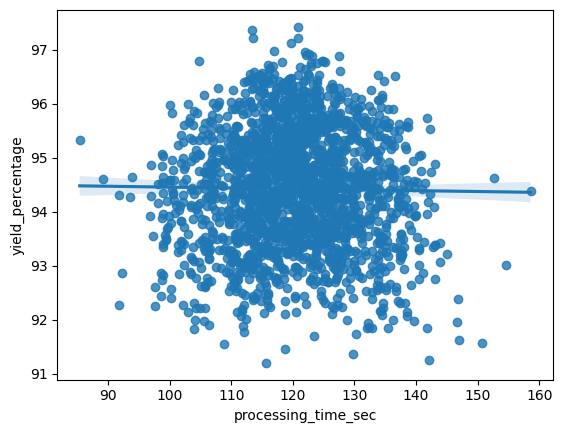

In [5]:
sns.regplot(data=yield_df, x='processing_time_sec', y='yield_percentage')

4.

In [7]:
print(pd.crosstab(yield_df['production_line'], yield_df['material_type']))

material_type    Type-X  Type-Y  Type-Z
production_line                        
Line-A              330     298     294
Line-B              320     324     320


In [ ]:
답안04 = '330'

5.

In [9]:
yield_df.groupby(['production_line'])[['temp_sensor_1', 'pressure_sensor', 'humidity', 'vibration_sensor']].mean()

,temp_sensor_1,pressure_sensor,humidity,vibration_sensor
production_line,,,,
Line-A,99.696071,49.992863,49.928922,0.995534
Line-B,100.201386,50.038326,50.180772,1.000232


6.

In [11]:
# 사전 제공 코드
num_cols = yield_df.select_dtypes(include='number').columns
print(num_cols)

Index(['temp_sensor_1', 'pressure_sensor', 'humidity', 'vibration_sensor',
       'processing_time_sec', 'power_consumption', 'operator_experience_years',
       'yield_percentage'],
      dtype='object')


In [12]:
yield_pre = yield_df.copy()

yield_pre[num_cols] = yield_pre[num_cols].fillna(yield_pre[num_cols].mean())
yield_pre['production_line'] = yield_pre['production_line'].replace({np.nan:'Line-A'})
yield_pre['material_type'] = yield_pre['material_type'].replace({np.nan:'Type-Z'})

7.

In [13]:
yield_encoded = pd.get_dummies(data=yield_pre, columns=['production_line', 'material_type'])

8.

In [14]:
X = yield_encoded.drop(columns=['yield_percentage'])
y = yield_encoded['yield_percentage']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=2024)

9.

In [15]:
# 사전 제공 코드
# 수치형 컬럼
num_scaling_cols = ['temp_sensor_1','pressure_sensor','humidity','vibration_sensor','processing_time_sec','power_consumption','operator_experience_years']

In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()

X_train_scaled[num_scaling_cols] = scaler.fit_transform(X_train[num_scaling_cols])
X_valid_scaled[num_scaling_cols] = scaler.transform(X_valid[num_scaling_cols])

10.

In [17]:
model_dt = dtr(max_depth=5, random_state=2024)

model_dt.fit(X_train_scaled, y_train)
dt_pred = model_dt.predict(X_valid_scaled)

11.

In [18]:
from sklearn.linear_model import ElasticNet

model_en = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=2024)

model_en.fit(X_train_scaled, y_train)

en_pred = model_en.predict(X_valid_scaled)

12.

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

print('DT')
print('MAE :', mean_absolute_error(y_valid, dt_pred))
print('R2 :', r2_score(y_valid, dt_pred))

print('EN')
print('MAE :', mean_absolute_error(y_valid, en_pred))
print('R2 :', r2_score(y_valid, en_pred))

DT
MAE : 0.5572732302710857
R2 : 0.6140247940504753
EN
MAE : 0.594507265934259
R2 : 0.5576512133038449


13.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
callbacks = [es]

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_data=(X_valid_scaled, y_valid), callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8630.8691 - val_loss: 8177.6743
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6523.1279 - val_loss: 3694.1826
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1087.1210 - val_loss: 133.8907
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 86.7944 - val_loss: 69.8096
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 65.6210 - val_loss: 60.8190
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.5792 - val_loss: 53.4214
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.7782 - val_loss: 45.6566
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.9160 - val_loss: 40.1119
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.5124 - val_loss: 34.7776
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.6271 - val_loss: 30.2746
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.4595 - val_loss: 26.4354
Epoch 12/100
47/47 ━━━━━━━━━━━

14.

In [21]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_process_data = np.array([[0.02424134,  0.9942146 ,  0.84412989,  0.00577765, -0.03352685, 0.02812489, -0.1759413, 0, 1, 0, 1, 0]])

In [23]:
predicted_yield_dl = model.predict(new_process_data)
print(predicted_yield_dl)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[96.2784]]
